In [68]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import joblib as joblib
import importlib as importlib
import scipy as sp
import qutip as qt

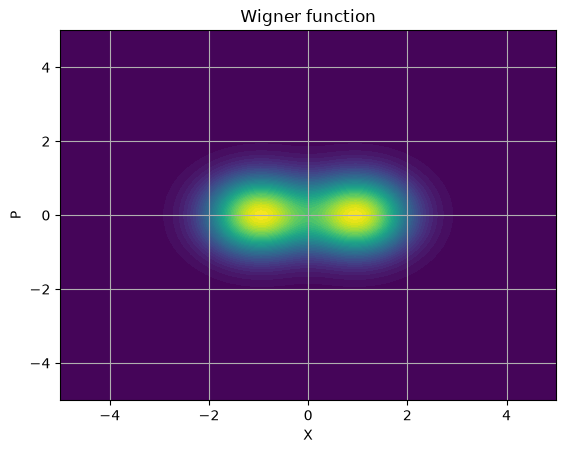

In [69]:
#coherent state from qutip
alpha = 0.7 + 0j
N = 100
coherent_state1 = qt.coherent(N, alpha)
coherent_state2 = qt.coherent(N, -alpha)
#plot in phase space
fig, ax = plt.subplots()
coherent_wigner1 = qt.wigner(coherent_state1, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
coherent_wigner2 = qt.wigner(coherent_state2, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
sum_wigner = coherent_wigner1 + coherent_wigner2
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), sum_wigner, 50)
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')
ax.grid()

Minimum error prob
$$
P_H = \cfrac12 \left( 1- \sqrt{1-|\langle\alpha |\beta \rangle|^2} \right)
$$

In [70]:
def min_error_prob(coherent_state1, coherent_state2):
    # Calculate the overlap between the two coherent states
    overlap = np.abs(coherent_state1.overlap(coherent_state2))**2
    # Calculate the minimum error probability using the Helstrom bound
    min_error_prob = 0.5 * (1 - np.sqrt(1 - overlap))
    return min_error_prob
P_H = min_error_prob(coherent_state1, coherent_state2)
print(f'Minimum error probability: {P_H:.4f}')

Minimum error probability: 0.0366


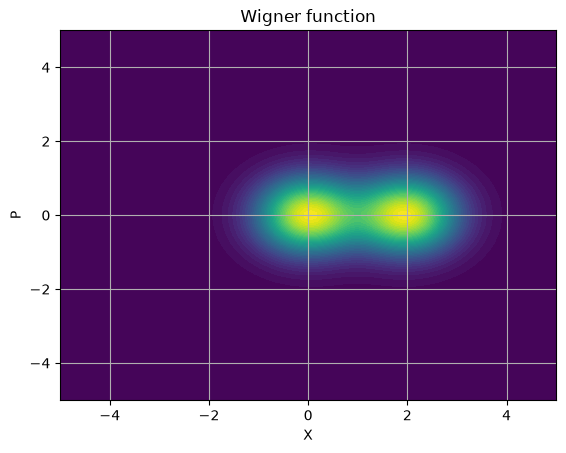

In [71]:
displace_alpha = qt.displace(N, alpha)
coherent_state1_displaced = displace_alpha * coherent_state1
coherent_state2_displaced = displace_alpha * coherent_state2
fig, ax = plt.subplots()
coherent_wigner1 = qt.wigner(coherent_state1_displaced, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
coherent_wigner2 = qt.wigner(coherent_state2_displaced, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
sum_wigner = coherent_wigner1 + coherent_wigner2
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), sum_wigner, 50)
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')
ax.grid()


In [72]:
def extract_alpha(coherent_state):
    a = qt.destroy(N)
    extracted_alpha = (coherent_state.dag() * a * coherent_state)
    return extracted_alpha

def kennedy_receiver(coherent1, coherent2, N):
    #extract alpha from coherent state
    alpha1 = extract_alpha(coherent1)
    alpha2 = extract_alpha(coherent2)
    #displace states by -alpha1
    displaced1 = qt.displace(N, -alpha1) * coherent1
    displaced2 = qt.displace(N, -alpha1) * coherent2
    #vacuum state
    vac_projector = qt.fock_dm(N, 0)
    prob_of_zero1 = qt.expect(vac_projector, displaced1)
    prob_of_zero2 = qt.expect(vac_projector, displaced2)
    prob_of_one1 = 1 - prob_of_zero1
    prob_of_one2 = 1 - prob_of_zero2
    #plot the before displacement and after displacement states in phase space
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))
    print(type(alpha1))
    maxR = np.max([np.abs(alpha1.real), np.abs(alpha2.real)])
    maxI = np.max([np.abs(alpha1.imag), np.abs(alpha2.imag)])
    plot_ranges_from_alpha = max(maxR, maxI) *3*np.sqrt(2)
    before_wigner1 = qt.wigner(coherent1, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    before_wigner2 = qt.wigner(coherent2, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    after_wigner1 = qt.wigner(displaced1, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    after_wigner2 = qt.wigner(displaced2, np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100))
    wigner_list = [before_wigner1, before_wigner2, after_wigner1, after_wigner2]
    for ax in [ax1, ax2, ax3, ax4]:
        ax.contourf(np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), np.linspace(-plot_ranges_from_alpha, plot_ranges_from_alpha, 100), wigner_list.pop(0), 50)
        ax.set_xlabel('X')
        ax.set_ylabel('P')
        ax.grid()
    ax1.set_title('Before displacement: State 1')
    ax2.set_title('Before displacement: State 2')
    ax3.set_title('After displacement: State 1')
    ax4.set_title('After displacement: State 2')
    print("After displacement:")
    print(f"If state 1 was sent, the probability of detecting a photon is: {prob_of_one1:.4f}")
    print(f"If state 2 was sent, the probability of detecting a photon is: {prob_of_one2:.4f}")



<class 'complex'>
After displacement:
If state 1 was sent, the probability of detecting a photon is: -0.0000
If state 2 was sent, the probability of detecting a photon is: 1.0000


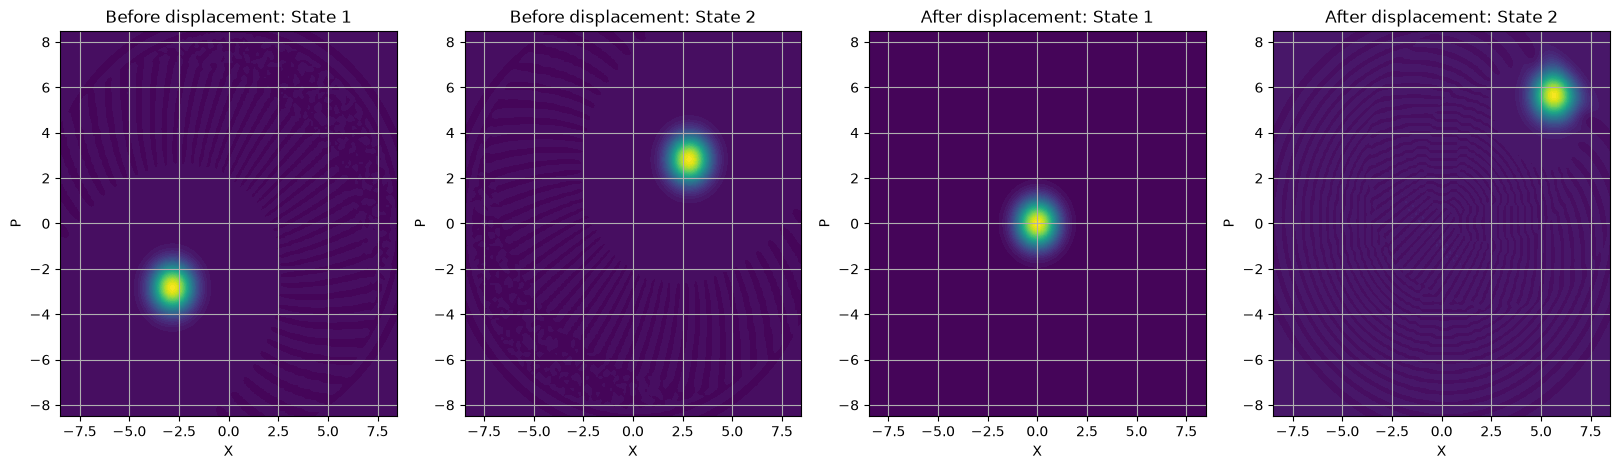

In [73]:
N = 50
alpha1 = -2 - 2j
alpha2 = 2 + 2j
coherent1 = qt.coherent(N, alpha1)
coherent2 = qt.coherent(N, alpha2)
kennedy_receiver(coherent1, coherent2, N)

In [ ]:
def U_BS_coherent(theta, eta,N):
    # Create the beam splitter unitary operator for a given angle theta and transmissivity eta
    a = qt.destroy(N)
    b = qt.destroy(N)
    U = (qt.tensor(qt.qeye(N), qt.qeye(N)) +
         (np.exp(1j * theta) - 1) * qt.tensor(a.dag() * a, qt.qeye(N)) +
         (np.sqrt(eta) - 1) * qt.tensor(qt.qeye(N), b.dag() * b))
    return U
def dolinar_receiver(alpha, num_splits, N, dark_count_rate=0.05):
    sliced_alpha = alpha / np.sqrt(num_splits)
    guess_alpha = np.abs(alpha)
    guess_sliced_alpha = guess_alpha / np.sqrt(num_splits)
    click_count = 0
    for step in range(num_splits):
        psi_in = qt.coherent(N, sliced_alpha)
        D = qt.displace(N, -guess_sliced_alpha)
        psi_displaced = (D * psi_in).unit()
        prob_0 = np.abs(psi_displaced.full()[0, 0])**2
        prob_1 = (1 - prob_0) + dark_count_rate #dark count
        prob_1 = min(prob_1, 1.0)
        prob_0 = 1 - prob_1
        detec_click = np.random.choice([False, True], p=[prob_0, prob_1])
        if detec_click:
            click_count += 1
            guess_sliced_alpha = -guess_sliced_alpha
    final = "+alpha" if guess_sliced_alpha > 0 else "-alpha"
    return final, click_count


In [206]:
alpha = 2
N = 50
state = qt.coherent(N, alpha)
num_splits = 10
dark_count_rate = 0.05
dolinar_result, clicks = dolinar_receiver(alpha, num_splits, N, dark_count_rate)
print(f"Dolinar receiver result: {dolinar_result}, Clicks detected: {clicks}")

Dolinar receiver result: +alpha, Clicks detected: 2


In [ ]:
# plot number of splits vs clicks
alpha = 1
dark_count_rate = 0.05
N = 50
runs_pr_split = 200


def evaluate_split_success(num_splits, alpha, dark_count_rate, N, runs_pr_split):
    correct_guesses = 0
    for _ in range(runs_pr_split):
        true_sign = np.random.choice([1, -1])
        true_signal = true_sign * alpha
        expected_result = "+alpha" if true_signal > 0 else "-alpha"
        dolinar_result, _ = dolinar_receiver(true_signal, num_splits, N, dark_count_rate)
        if dolinar_result == expected_result:
            correct_guesses += 1
    return correct_guesses / runs_pr_split


Evaluating split counts: 100%|██████████| 20/20 [00:00<00:00, 79.35it/s] 


[0.965, 0.915, 0.915, 0.955, 0.925, 0.925, 0.92, 0.875, 0.885, 0.87, 0.9, 0.91, 0.84, 0.86, 0.855, 0.865, 0.84, 0.89, 0.825, 0.81]


In [ ]:
splitrange = range(1, 21)

success_rates = joblib.Parallel(n_jobs=-1, prefer="threads")(
    joblib.delayed(evaluate_split_success)(
        num_splits, alpha, dark_count_rate, N, runs_pr_split
    )
    for num_splits in tqdm.tqdm(splitrange, desc="Evaluating split counts")
)

print(success_rates)

Text(0, 0.5, 'Success Rate')

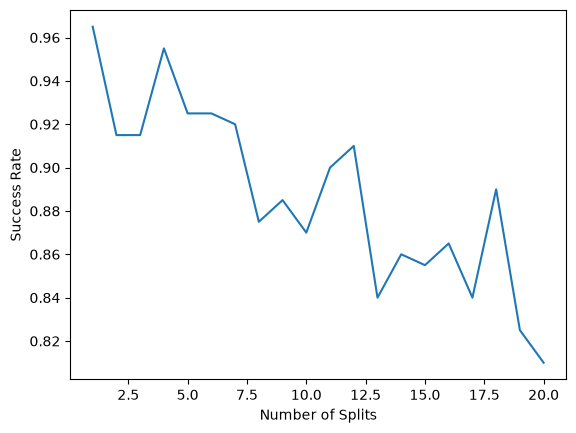

In [211]:
fig, ax = plt.subplots()
ax.plot(splitrange, success_rates)
ax.set_xlabel("Number of Splits")
ax.set_ylabel("Success Rate")